# Capítulo 9 — Regresión logística: clasificar con probabilidades

En este cuaderno estudiaremos un modelo de clasificación que estima probabilidades. Aunque su nombre contiene la palabra *regresión*, la regresión logística se usa habitualmente para decidir entre categorías.

Recorreremos la idea principal del modelo: una combinación lineal de las variables, la función sigmoide, una probabilidad y un umbral que finalmente produce una etiqueta.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar por qué la regresión logística sirve para clasificar;
- reconocer el papel de la función sigmoide;
- obtener e interpretar probabilidades con `predict_proba()`;
- comprobar cómo un umbral transforma una probabilidad en una clase;
- interpretar el signo de los coeficientes con cautela;
- visualizar la frontera lineal del modelo;
- reconocer ventajas y limitaciones básicas de la regresión logística.

## 1. Importar las herramientas

Continuaremos con el dataset Wine. Usaremos dos variables numéricas para poder representar las observaciones, las probabilidades y la frontera de decisión en un plano.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Preparar un problema binario

La pregunta será la misma que en prácticas anteriores: **¿la muestra pertenece al Cultivar 0 o a otro cultivar?**

Para que la clase positiva quede definida sin ambigüedad, usaremos el código `1` para **Cultivar 0** y `0` para **Otros**. Estos números son etiquetas, no cantidades.

In [2]:
wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["cultivar"] = pd.Series(wine.target).map({
    0: "Cultivar 0",
    1: "Cultivar 1",
    2: "Cultivar 2",
})

X = df[["alcohol", "color_intensity"]]
y = (df["cultivar"] == "Cultivar 0").astype(int)

pd.concat([X.head(), y.head().rename("clase")], axis=1)

,alcohol,color_intensity,clase
0,14.23,5.64,1
1,13.20,4.38,1
2,13.16,5.68,1
3,14.37,7.80,1
4,13.24,4.32,1


`X` contiene el porcentaje de alcohol y la intensidad de color. La variable `y` contiene la clase que queremos predecir: `1` representa Cultivar 0 y `0` reúne los demás cultivares.

In [3]:
conteo_clases = (
    y.map({1: "Cultivar 0", 0: "Otros"})
     .value_counts()
     .rename_axis("clase")
     .to_frame("cantidad")
)

conteo_clases

,cantidad
clase,
Otros,119
Cultivar 0,59


El conjunto tiene 59 muestras del Cultivar 0 y 119 de otros cultivares. La clase positiva es menos frecuente, pero está suficientemente representada para esta demostración.

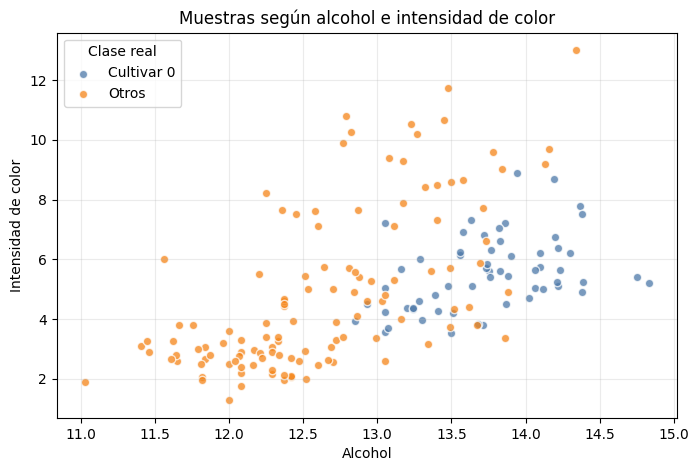

In [4]:
plt.figure(figsize=(8, 5))

colores = {1: "#4C78A8", 0: "#F58518"}
etiquetas = {1: "Cultivar 0", 0: "Otros"}

for clase in [1, 0]:
    mascara = y == clase
    plt.scatter(
        X.loc[mascara, "alcohol"],
        X.loc[mascara, "color_intensity"],
        label=etiquetas[clase],
        color=colores[clase],
        alpha=0.75,
        edgecolor="white"
    )

plt.title("Muestras según alcohol e intensidad de color")
plt.xlabel("Alcohol")
plt.ylabel("Intensidad de color")
plt.grid(alpha=0.25)
plt.legend(title="Clase real")
plt.show()

Las clases muestran cierta organización, aunque también hay una zona de superposición. La regresión logística intentará separar ambas categorías mediante una frontera recta y asignará una probabilidad a cada punto.

## 3. De una puntuación lineal a una probabilidad

El nombre *regresión* se debe a que el modelo no comienza produciendo una categoría: construye primero una puntuación continua a partir de una combinación lineal. La clasificación aparece después, cuando esa puntuación se transforma en probabilidad y se aplica un umbral.

La regresión logística comienza calculando una puntuación lineal:

$$z = b_0 + b_1x_1 + b_2x_2$$

Esa puntuación puede tomar cualquier valor. Para convertirla en un número entre 0 y 1 se aplica la función sigmoide:

$$p = \frac{1}{1 + e^{-z}}$$

No necesitamos desarrollar toda la matemática del modelo. Nos alcanza con entender que `z` resume la información de las variables y que la sigmoide transforma ese valor en una probabilidad.

Veamos algunos valores concretos.

In [5]:
valores_z = np.array([-4, -2, 0, 2, 4])
probabilidades = 1 / (1 + np.exp(-valores_z))

pd.DataFrame({
    "puntuacion_z": valores_z,
    "sigmoide_z": probabilidades,
}).round(3)

,puntuacion_z,sigmoide_z
0,-4,0.018
1,-2,0.119
2,0,0.500
3,2,0.881
4,4,0.982


Una puntuación `z` negativa produce una probabilidad menor que 0,5; una puntuación positiva produce una probabilidad mayor que 0,5. Cuando `z` vale cero, la sigmoide devuelve exactamente 0,5.

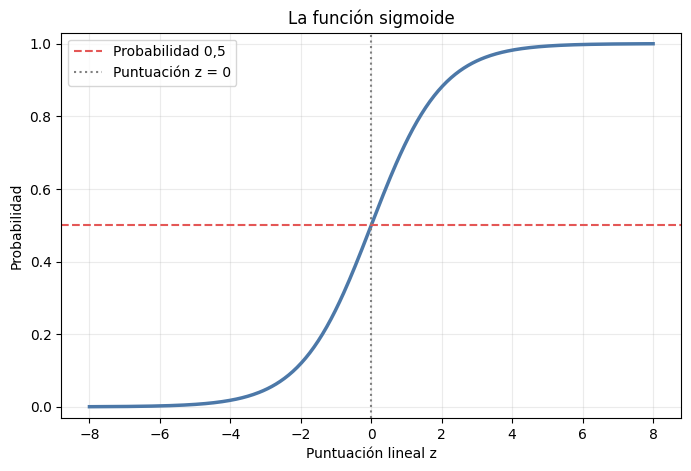

In [6]:
z = np.linspace(-8, 8, 400)
sigmoide = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoide, color="#4C78A8", linewidth=2.5)
plt.axhline(0.5, color="#E45756", linestyle="--", label="Probabilidad 0,5")
plt.axvline(0, color="gray", linestyle=":", label="Puntuación z = 0")
plt.title("La función sigmoide")
plt.xlabel("Puntuación lineal z")
plt.ylabel("Probabilidad")
plt.ylim(-0.03, 1.03)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

La curva tiene forma de S. Las puntuaciones muy negativas se acercan a 0 y las muy positivas se acercan a 1, pero la función nunca sale del intervalo de probabilidades.

## 4. Entrenar el modelo

Separaremos entrenamiento y prueba como vimos en capítulos anteriores. Mantendremos la proporción de clases con `stratify` y ajustaremos el escalado solamente con los datos de entrenamiento.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba:        {X_test.shape}")

Entrenamiento: (133, 2)
Prueba:        (45, 2)


El modelo aprenderá con 133 muestras. Las 45 restantes quedarán reservadas para observar sus probabilidades sin haberlas usado durante el ajuste.

In [8]:
modelo = Pipeline([
    ("escalador", StandardScaler()),
    ("logistica", LogisticRegression(random_state=42))
])

modelo.fit(X_train, y_train)

print("Clases internas del modelo:", modelo.named_steps["logistica"].classes_)

Clases internas del modelo: [0 1]


El `Pipeline` aplica primero el escalado aprendido con entrenamiento y luego la regresión logística. Las clases internas aparecen como `[0, 1]`: por eso la segunda columna de `predict_proba()` corresponderá a la probabilidad de **Cultivar 0**.

Usamos un pipeline para mantener juntos el escalado y el modelo. En este cuaderno, lo importante no es estudiar el pipeline, sino observar cómo funciona la regresión logística una vez que las variables están en una escala adecuada.

`random_state=42` forma parte de la configuración reproducible que ya conocemos. No modifica la idea central estudiada en este capítulo.

## 5. Observar probabilidades y etiquetas

Para cada fila, `predict_proba()` devuelve una probabilidad por clase. Ambas deben sumar 1. La predicción final puede obtenerse con `.predict()`.

In [9]:
probabilidades_test = modelo.predict_proba(X_test)
predicciones_test = modelo.predict(X_test)

resultados = X_test.reset_index(drop=True).copy()
resultados["clase_real"] = y_test.reset_index(drop=True).map({
    1: "Cultivar 0",
    0: "Otros",
})
resultados["prob_otros"] = probabilidades_test[:, 0]
resultados["prob_cultivar_0"] = probabilidades_test[:, 1]
resultados["clase_predicha"] = pd.Series(predicciones_test).map({
    1: "Cultivar 0",
    0: "Otros",
})

resultados.head(10).round(3)

,alcohol,color_intensity,clase_real,prob_otros,prob_cultivar_0,clase_predicha
0,13.45,10.68,Otros,0.784,0.216,Otros
1,14.12,5.00,Cultivar 0,0.084,0.916,Cultivar 0
2,14.83,5.20,Cultivar 0,0.009,0.991,Cultivar 0
3,12.52,2.00,Otros,0.884,0.116,Otros
4,13.78,9.58,Otros,0.480,0.520,Cultivar 0
5,13.90,6.10,Cultivar 0,0.200,0.800,Cultivar 0
6,13.76,5.40,Cultivar 0,0.247,0.753,Cultivar 0
7,12.33,3.27,Otros,0.952,0.048,Otros
8,13.29,6.00,Cultivar 0,0.640,0.360,Otros
9,13.71,3.80,Cultivar 0,0.203,0.797,Cultivar 0


La tabla permite distinguir dos salidas: la probabilidad estimada y la etiqueta resultante. Algunas probabilidades están cerca de 0 o de 1; otras quedan en una zona intermedia y expresan una decisión menos marcada según este modelo.

In [10]:
suma_probabilidades = (
    resultados["prob_otros"] + resultados["prob_cultivar_0"]
)

print("Primeras cinco sumas:")
print(suma_probabilidades.head().round(3).to_list())

Primeras cinco sumas:
[1.0, 1.0, 1.0, 1.0, 1.0]


Cada par de probabilidades estimadas suma 1 porque, en este problema binario, las dos clases consideradas son complementarias: una muestra se clasifica como Cultivar 0 o como Otros.

## 6. Reconstruir una probabilidad paso a paso

Tomaremos una muestra hipotética cercana a la zona de decisión. Primero el `Pipeline` escalará sus valores. Después, la regresión logística calculará `z` y aplicará la sigmoide.

In [11]:
muestra_nueva = pd.DataFrame({
    "alcohol": [13.4],
    "color_intensity": [5.0],
})

muestra_nueva

,alcohol,color_intensity
0,13.4,5.0


In [12]:
escalador = modelo.named_steps["escalador"]
logistica = modelo.named_steps["logistica"]

muestra_escalada = escalador.transform(muestra_nueva)
z_manual = logistica.intercept_[0] + np.sum(
    logistica.coef_[0] * muestra_escalada[0]
)
probabilidad_manual = 1 / (1 + np.exp(-z_manual))
probabilidad_modelo = modelo.predict_proba(muestra_nueva)[0, 1]

print(f"Puntuación lineal z: {z_manual:.3f}")
print(f"Probabilidad calculada con la sigmoide: {probabilidad_manual:.3f}")
print(f"Probabilidad entregada por el modelo:   {probabilidad_modelo:.3f}")

Puntuación lineal z: 0.045
Probabilidad calculada con la sigmoide: 0.511
Probabilidad entregada por el modelo:   0.511


Ambos cálculos coinciden. El modelo estima una probabilidad apenas superior a 0,5 para Cultivar 0. Esto no afirma que la muestra pertenezca con certeza a esa clase: es una estimación producida por el modelo a partir de las variables disponibles.

## 7. Del valor probable a la clase: el umbral

El umbral habitual es 0,5. Si la probabilidad de la clase positiva es igual o superior, asignamos `1`; si es menor, asignamos `0`. Sin embargo, el umbral puede cambiar según el problema.

In [13]:
probabilidad_nueva = modelo.predict_proba(muestra_nueva)[0, 1]

for umbral in [0.3, 0.5, 0.7]:
    clase = "Cultivar 0" if probabilidad_nueva >= umbral else "Otros"
    print(f"Umbral {umbral:.1f} -> {clase}")

Umbral 0.3 -> Cultivar 0
Umbral 0.5 -> Cultivar 0
Umbral 0.7 -> Otros


La probabilidad no cambió: lo que cambió fue la regla utilizada para convertirla en una etiqueta. Con umbrales más bajos es más fácil asignar la clase positiva; con umbrales más altos se exige mayor probabilidad.

In [14]:
resumen_umbrales = []

for umbral in [0.3, 0.5, 0.7]:
    cantidad_positivas = int(
        (resultados["prob_cultivar_0"] >= umbral).sum()
    )
    resumen_umbrales.append({
        "umbral": umbral,
        "predicciones_cultivar_0": cantidad_positivas,
        "predicciones_otros": len(resultados) - cantidad_positivas,
    })

pd.DataFrame(resumen_umbrales)

,umbral,predicciones_cultivar_0,predicciones_otros
0,0.3,22,23
1,0.5,16,29
2,0.7,11,34


Al elevar el umbral de 0,3 a 0,7 disminuye la cantidad de casos clasificados como Cultivar 0. Esta tabla describe el comportamiento de la regla, pero no permite decidir por sí sola cuál umbral es mejor. Para eso habría que analizar los tipos de error y el contexto, cuestiones que retomaremos en capítulos posteriores.

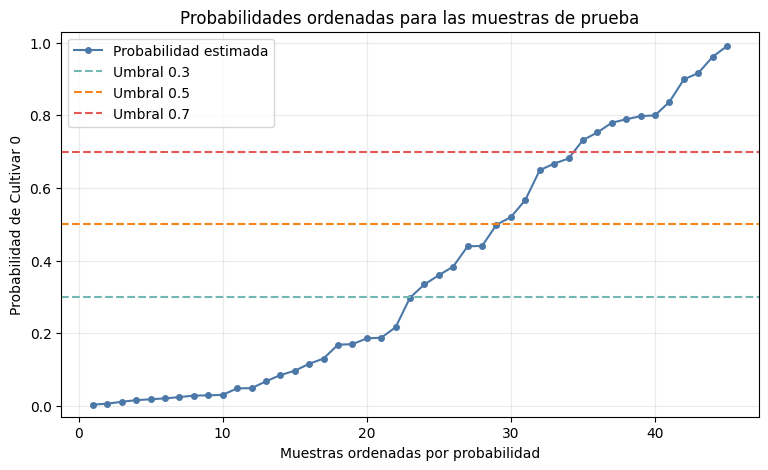

In [15]:
probabilidades_ordenadas = np.sort(resultados["prob_cultivar_0"].to_numpy())

plt.figure(figsize=(9, 5))
plt.plot(
    range(1, len(probabilidades_ordenadas) + 1),
    probabilidades_ordenadas,
    marker="o",
    markersize=4,
    color="#4C78A8",
    linewidth=1.5,
    label="Probabilidad estimada"
)

for umbral, color in [(0.3, "#72B7B2"), (0.5, "#F58518"), (0.7, "#E45756")]:
    plt.axhline(umbral, linestyle="--", color=color, label=f"Umbral {umbral}")

plt.title("Probabilidades ordenadas para las muestras de prueba")
plt.xlabel("Muestras ordenadas por probabilidad")
plt.ylabel("Probabilidad de Cultivar 0")
plt.ylim(-0.03, 1.03)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

Cada línea horizontal produciría una división distinta entre las etiquetas. Los puntos próximos a una línea son los que pueden cambiar de clase cuando se modifica ese umbral.

## 8. Interpretar los coeficientes

La regresión logística aprendió un coeficiente para cada variable. Como la clase positiva es Cultivar 0:

- un coeficiente positivo empuja la estimación hacia esa clase;
- un coeficiente negativo la aleja de esa clase;
- un valor absoluto mayor indica un cambio más fuerte en la puntuación `z`, considerando aquí que las variables fueron estandarizadas.

In [16]:
coeficientes = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": logistica.coef_[0],
})

coeficientes["direccion_hacia_cultivar_0"] = np.where(
    coeficientes["coeficiente"] > 0,
    "Aumenta la puntuación",
    "Reduce la puntuación"
)

coeficientes.round(3)

,variable,coeficiente,direccion_hacia_cultivar_0
0,alcohol,2.647,Aumenta la puntuación
1,color_intensity,-0.595,Reduce la puntuación


Manteniendo constante la otra variable, un mayor valor estandarizado de alcohol eleva la puntuación hacia Cultivar 0. La intensidad de color tiene un coeficiente negativo en este ajuste y la reduce.

El coeficiente de alcohol tiene mayor magnitud, pero esta lectura depende de los datos, del escalado y de las demás variables incluidas. No demuestra que una variable cause la pertenencia a un cultivar.

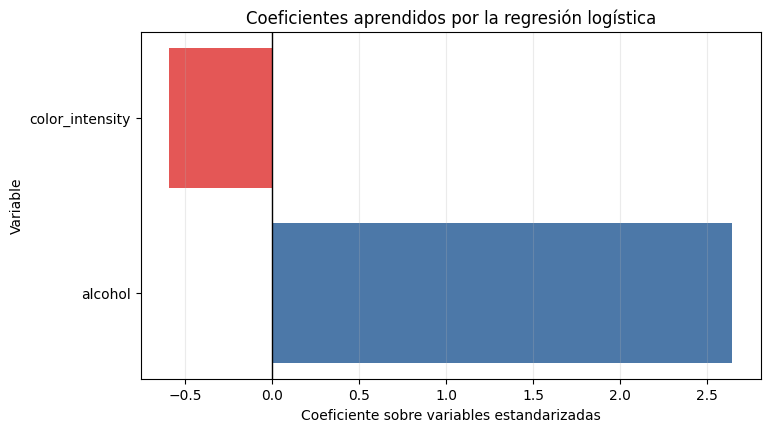

In [17]:
plt.figure(figsize=(8, 4.5))

colores_coef = [
    "#4C78A8" if valor > 0 else "#E45756"
    for valor in coeficientes["coeficiente"]
]

plt.barh(
    coeficientes["variable"],
    coeficientes["coeficiente"],
    color=colores_coef
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Coeficientes aprendidos por la regresión logística")
plt.xlabel("Coeficiente sobre variables estandarizadas")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.25)
plt.show()

El gráfico resume la dirección y magnitud de los coeficientes en este modelo. Si incorporáramos otras variables, observaciones o transformaciones, sus valores podrían cambiar.

## 9. Visualizar la frontera de decisión

Calcularemos la probabilidad sobre una cuadrícula. El color de fondo mostrará la probabilidad estimada de Cultivar 0 y la línea negra marcará los puntos donde esa probabilidad vale 0,5.

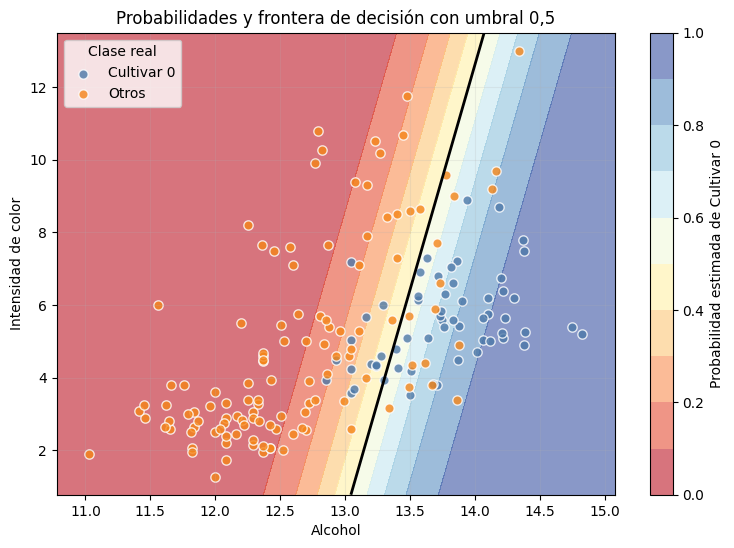

In [18]:
margen_alcohol = 0.25
margen_color = 0.5

alcohol_grid, color_grid = np.meshgrid(
    np.linspace(X["alcohol"].min() - margen_alcohol,
                X["alcohol"].max() + margen_alcohol, 250),
    np.linspace(X["color_intensity"].min() - margen_color,
                X["color_intensity"].max() + margen_color, 250)
)

cuadricula = pd.DataFrame({
    "alcohol": alcohol_grid.ravel(),
    "color_intensity": color_grid.ravel(),
})

prob_grid = modelo.predict_proba(cuadricula)[:, 1].reshape(alcohol_grid.shape)

plt.figure(figsize=(9, 6))

fondo = plt.contourf(
    alcohol_grid,
    color_grid,
    prob_grid,
    levels=np.linspace(0, 1, 11),
    cmap="RdYlBu",
    alpha=0.6
)

plt.contour(
    alcohol_grid,
    color_grid,
    prob_grid,
    levels=[0.5],
    colors="black",
    linewidths=2
)

for clase in [1, 0]:
    mascara = y == clase
    plt.scatter(
        X.loc[mascara, "alcohol"],
        X.loc[mascara, "color_intensity"],
        label=etiquetas[clase],
        color=colores[clase],
        edgecolor="white",
        alpha=0.8,
        s=45
    )

barra = plt.colorbar(fondo)
barra.set_label("Probabilidad estimada de Cultivar 0")

plt.title("Probabilidades y frontera de decisión con umbral 0,5")
plt.xlabel("Alcohol")
plt.ylabel("Intensidad de color")
plt.grid(alpha=0.2)
plt.legend(title="Clase real")
plt.show()

La probabilidad cambia gradualmente a ambos lados de la línea. La frontera es recta porque el modelo parte de una combinación lineal de las variables. Esta sencillez facilita la interpretación, pero puede ser una limitación si las clases siguen una forma más compleja.

También observamos puntos reales a ambos lados de la frontera que no coinciden con la región predominante de su clase. Una frontera simple no separa necesariamente todos los casos.

## 10. Ventajas y limitaciones

Resumamos lo que esta práctica permite observar.

In [19]:
balance_modelo = pd.DataFrame({
    "Ventajas": [
        "Entrega probabilidades por clase",
        "Sus coeficientes permiten una lectura básica",
        "Es eficiente y ofrece una referencia inicial",
        "Su predicción es rápida",
    ],
    "Limitaciones": [
        "Produce una frontera lineal",
        "Los coeficientes dependen del escalado y de las variables",
        "Puede verse afectada por valores extremos y clases desbalanceadas",
        "Una probabilidad estimada no equivale a certeza",
    ],
})

balance_modelo

,Ventajas,Limitaciones
0,Entrega probabilidades por clase,Produce una frontera lineal
1,Sus coeficientes permiten una lectura básica,Los coeficientes dependen del escalado y de la...
2,Es eficiente y ofrece una referencia inicial,Puede verse afectada por valores extremos y cl...
3,Su predicción es rápida,Una probabilidad estimada no equivale a certeza


La regresión logística aprendió un coeficiente para cada variable. Como la clase positiva es Cultivar 0, esta interpretación es inicial y debe hacerse con cautela:

- un coeficiente positivo empuja la estimación hacia esa clase;
- un coeficiente negativo la aleja de esa clase;
- un valor absoluto mayor indica un cambio más fuerte en la puntuación `z`, considerando aquí que las variables fueron estandarizadas.

## 11. Una pequeña exploración

Probá modificar los valores de las tres muestras siguientes. Podés guiarte por rangos aproximados del gráfico: alcohol entre 11 y 15, e intensidad de color entre 1 y 13.

Observá cómo cambia la probabilidad y compará la etiqueta obtenida con umbrales de 0,5 y 0,7.

Mantené los mismos nombres de columnas: `alcohol` y `color_intensity`.

In [20]:
muestras_para_probar = pd.DataFrame({
    "alcohol": [12.5, 13.4, 14.2],
    "color_intensity": [4.0, 5.0, 7.0],
})

prob_prueba = modelo.predict_proba(muestras_para_probar)[:, 1]

exploracion = muestras_para_probar.copy()
exploracion["prob_cultivar_0"] = prob_prueba
exploracion["clase_umbral_0_5"] = np.where(
    prob_prueba >= 0.5, "Cultivar 0", "Otros"
)
exploracion["clase_umbral_0_7"] = np.where(
    prob_prueba >= 0.7, "Cultivar 0", "Otros"
)

exploracion.round(3)

,alcohol,color_intensity,prob_cultivar_0,clase_umbral_0_5,clase_umbral_0_7
0,12.5,4.0,0.068,Otros,Otros
1,13.4,5.0,0.511,Cultivar 0,Otros
2,14.2,7.0,0.893,Cultivar 0,Cultivar 0


Las probabilidades varían de forma gradual, mientras que las etiquetas cambian al cruzar el umbral. Si modificás una muestra hasta dejarla cerca de 0,5, una variación pequeña en sus variables puede hacer que pase de una clase a la otra.

## Cierre

La regresión logística clasifica a partir de probabilidades. Primero construye una puntuación lineal, luego la convierte mediante la sigmoide y finalmente aplica un umbral para producir una etiqueta.

En este recorrido comprobamos que la probabilidad y la clase predicha son resultados relacionados, pero diferentes. También vimos que los coeficientes aportan información sobre la dirección de cada variable, aunque deben interpretarse dentro del modelo y sin atribuir causalidad.

Todavía no analizamos formalmente cuántos aciertos o qué tipos de errores produce el modelo. Ese será el paso necesario para evaluar su desempeño con mayor responsabilidad.

## Para pensar

1. ¿Por qué la regresión logística puede usarse para clasificar aunque incluya la palabra *regresión*?
2. ¿Qué papel cumple la función sigmoide?
3. ¿Qué cambia y qué permanece igual cuando modificamos el umbral de decisión?
4. ¿Cómo interpretarías un coeficiente positivo para la clase `1`?
5. ¿Por qué un coeficiente grande no demuestra una relación causal?
6. ¿En qué situación una frontera lineal podría resultar demasiado simple?